# Klasifikasi Gambar Menggunakan TensorFlow

In [1]:
# Import needed libraries
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data_path = 'dataset/Training' # assuming training data is in root path
filepaths = []
labels = []

folds = os.listdir(train_data_path)
for fold in folds:
    fold_path = os.path.join(train_data_path, fold)
    if os.path.isdir(fold_path):
        filelists = os.listdir(fold_path)

        for file in filelists:
            filepaths.append(os.path.join(fold_path, file))
            labels.append(fold)

# Concat data paths with labels
fseries = pd.Series(filepaths , name='filepaths')
lseries = pd.Series(labels , name='labels')
train_df = pd.concat([fseries , lseries] , axis=1)

In [3]:
train_df

,filepaths,labels
0,dataset/Training\glioma\Tr-glTr_0000.jpg,glioma
1,dataset/Training\glioma\Tr-glTr_0001.jpg,glioma
2,dataset/Training\glioma\Tr-glTr_0002.jpg,glioma
3,dataset/Training\glioma\Tr-glTr_0003.jpg,glioma
4,dataset/Training\glioma\Tr-glTr_0004.jpg,glioma
...,...,...
5707,dataset/Training\pituitary\Tr-pi_1452.jpg,pituitary
5708,dataset/Training\pituitary\Tr-pi_1453.jpg,pituitary
5709,dataset/Training\pituitary\Tr-pi_1454.jpg,pituitary
5710,dataset/Training\pituitary\Tr-pi_1455.jpg,pituitary


In [4]:
test_data_path = 'dataset/Testing' # assuming training data is in root path
filepaths = []
labels = []

folds = os.listdir(test_data_path)
for fold in folds:
    fold_path = os.path.join(test_data_path, fold)
    if os.path.isdir(fold_path):
        filelists = os.listdir(fold_path)

        for file in filelists:
            filepaths.append(os.path.join(fold_path, file))
            labels.append(fold)

# Concat data paths with labels
fseries = pd.Series(filepaths , name='filepaths')
lseries = pd.Series(labels , name='labels')
test_df = pd.concat([fseries , lseries] , axis=1)

In [5]:
test_df

,filepaths,labels
0,dataset/Testing\glioma\Te-glTr_0000.jpg,glioma
1,dataset/Testing\glioma\Te-glTr_0001.jpg,glioma
2,dataset/Testing\glioma\Te-glTr_0002.jpg,glioma
3,dataset/Testing\glioma\Te-glTr_0003.jpg,glioma
4,dataset/Testing\glioma\Te-glTr_0004.jpg,glioma
...,...,...
1306,dataset/Testing\pituitary\Te-pi_0295.jpg,pituitary
1307,dataset/Testing\pituitary\Te-pi_0296.jpg,pituitary
1308,dataset/Testing\pituitary\Te-pi_0297.jpg,pituitary
1309,dataset/Testing\pituitary\Te-pi_0298.jpg,pituitary


In [6]:
valid, test = train_test_split(train_df, test_size=0.5, stratify=train_df['labels'], random_state=42)

In [7]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 2856 validated image filenames belonging to 4 classes.
Found 2856 validated image filenames belonging to 4 classes.


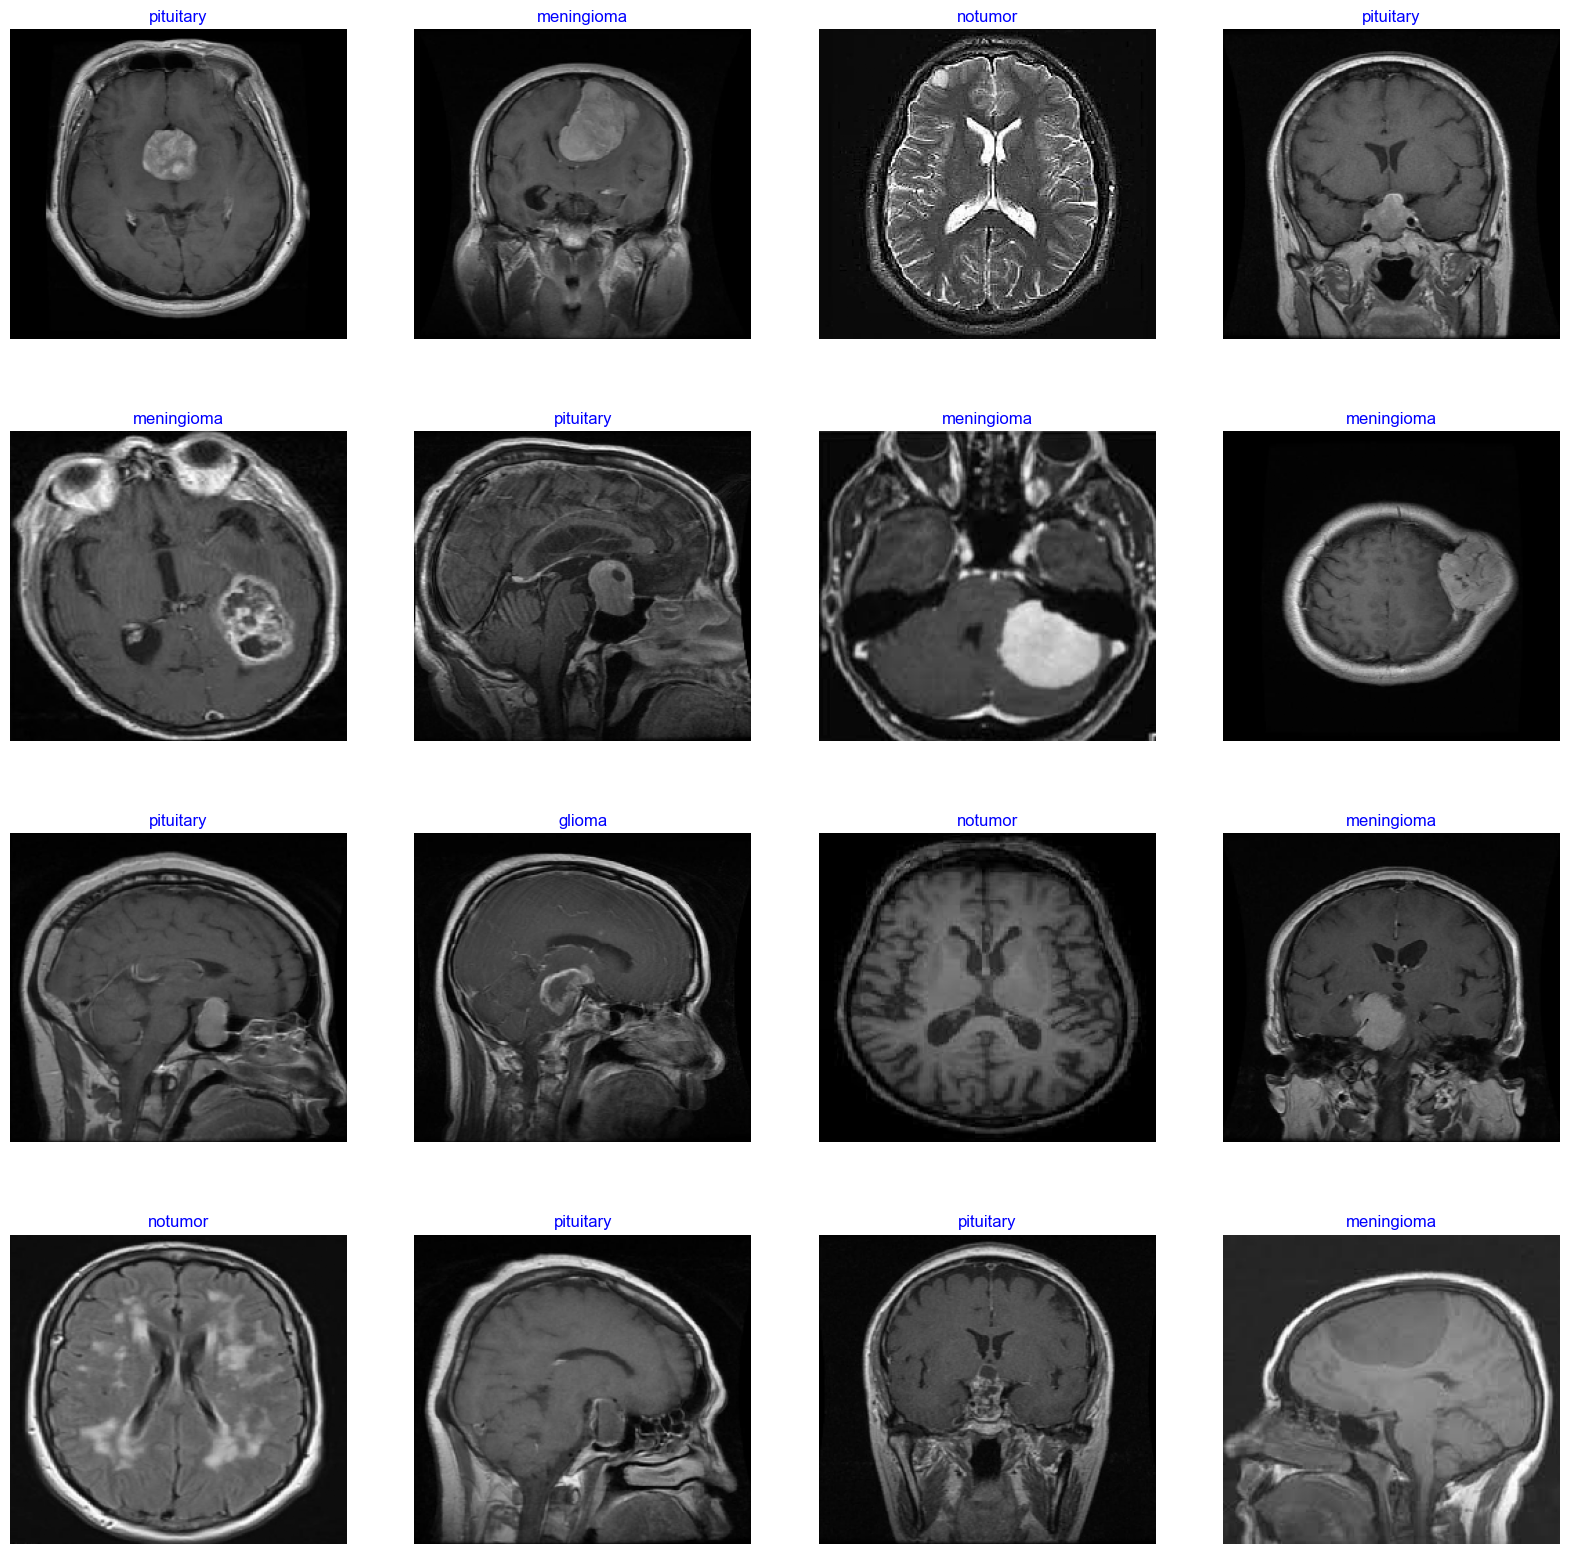

In [8]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color = 'blue', fontsize = 12)
    plt.axis('off')
plt.show()

In [9]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [10]:
# Training Model
epochs = 10

history = model.fit(
    train_gen,
    epochs=epochs,
    verbose = 1,
    validation_data = valid_gen,
    shuffle = True
)
                    

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 373s 913ms/step - accuracy: 0.4979 - loss: 7.6347 - val_accuracy: 0.3725 - val_loss: 5.5907
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 312s 873ms/step - accuracy: 0.4998 - loss: 4.6240 - val_accuracy: 0.4986 - val_loss: 3.7497
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 295s 826ms/step - accuracy: 0.5103 - loss: 3.1254 - val_accuracy: 0.5098 - val_loss: 2.5526
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 309s 866ms/step - accuracy: 0.5179 - loss: 2.2223 - val_accuracy: 0.5298 - val_loss: 1.8560
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 297s 832ms/step - accuracy: 0.5280 - loss: 1.7005 - val_accuracy: 0.5494 - val_loss: 1.5223
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 313s 878ms/step - accuracy: 0.5270 - loss: 1.4257 - val_accuracy: 0.5340 - val_loss: 1.2860
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 318s 890ms/step - accuracy: 0.5273 - loss: 1.2581 - val_accuracy: 0.5350 - val_loss: 1.1627
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 324s 907ms/step - accuracy: 0.5285 -

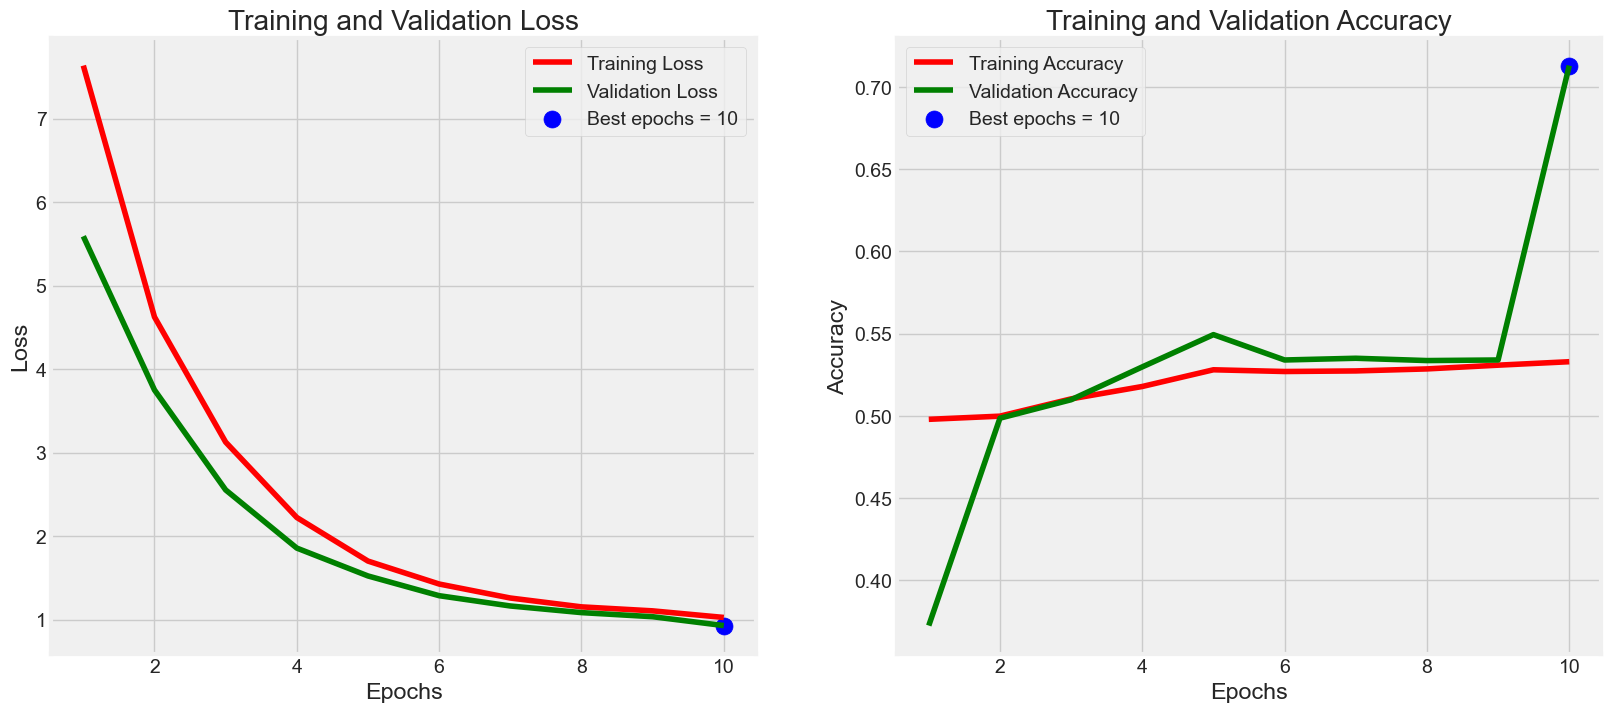

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.7031 - loss: 0.9100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.7617 - loss: 0.9433
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.6719 - loss: 0.9504
Train Loss:  0.909977376461029
Train Accuracy:  0.703125
--------------------
Validation Loss:  0.9432703256607056
Validation Accuracy:  0.76171875
--------------------
Test Loss:  0.9503917694091797
Test Accuracy:  0.671875
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 179ms/step


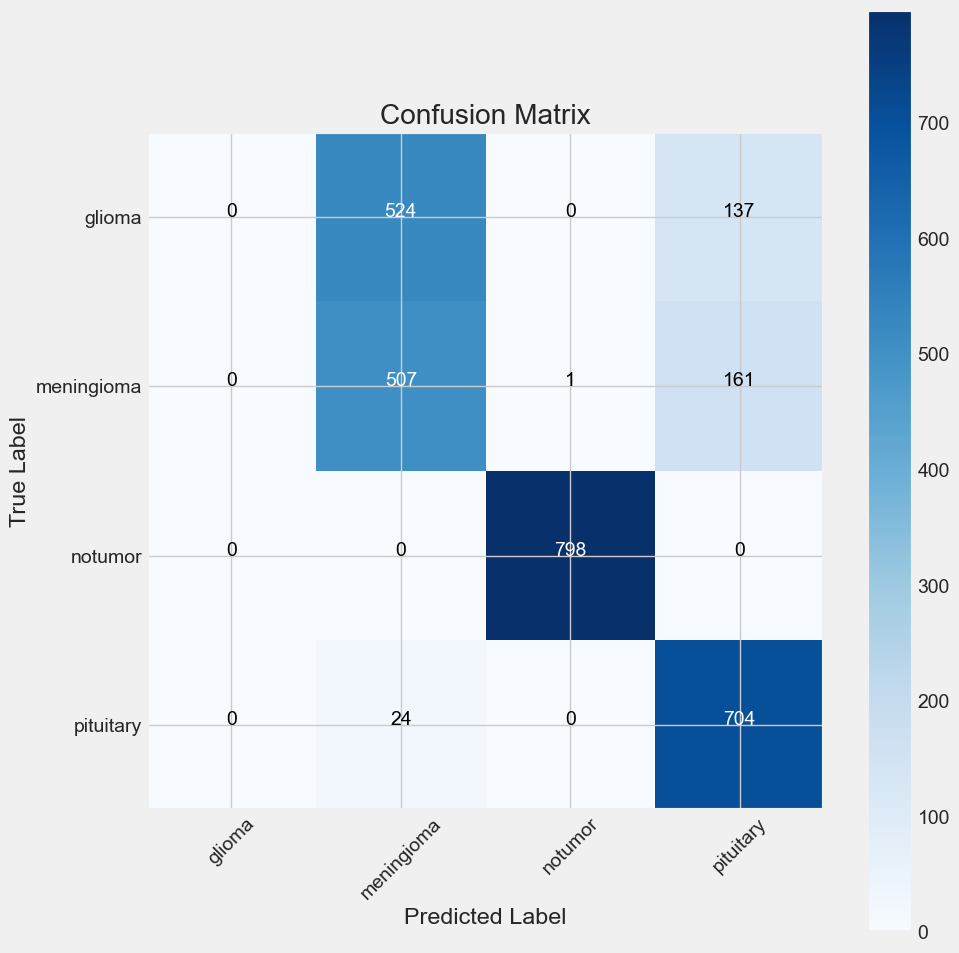

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       661
  meningioma       0.48      0.76      0.59       669
     notumor       1.00      1.00      1.00       798
   pituitary       0.70      0.97      0.81       728

    accuracy                           0.70      2856
   macro avg       0.55      0.68      0.60      2856
weighted avg       0.57      0.70      0.62      2856



In [11]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show()

###

train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

###

preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

###
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

###
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))